Importing Librarires

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

Load Macroeconomics Data

In [2]:
dmacro=pd.read_csv('Other_Macroeconomic_Indicators1.csv')
dmacro

,Reporting Date,NSE S&P CNX NIFTY,BSE BANKEX,REPO RATE (OVERNIGHT),REVERSE REPO RATE (OVERNIGHT),DAILY CALL MONEY RATE -HIGH,DAILY CALL MONEY RATE - LOW,RBI'S REFERENCE RATE: INR PER USD
0,NaN,Index,Index,Per cent,Per cent,Per cent,Per cent,Rupees
1,20-Nov-25,NaN,NaN,NaN,NaN,NaN,NaN,88.6915
2,19-Nov-25,26052.65,66481.53,NaN,NaN,5.45,4.85,88.4558
3,18-Nov-25,25910.05,66102.82,NaN,NaN,5.45,4.75,88.6344
4,17-Nov-25,26013.45,66156.8,NaN,NaN,5.45,4.75,88.63
...,...,...,...,...,...,...,...,...
3851,05-May-15,8324.8,21196.02,7.5,6.5,7.8,5.75,63.5194
3852,04-May-15,8331.95,21231.23,7.5,6.5,NaN,NaN,NaN
3853,03-May-15,wh,wh,wh,wh,wh,wh,wh
3854,02-May-15,NaN,NaN,7.5,6.5,6.92,4.5,NaN


MAcroeconomics Data Cleaning :Converting dates in Uniform Date format and extracting 1 year data and removing unnecessary columns

In [3]:
dmacroclean1=dmacro.copy()
dmacroclean1['Reporting Date']=pd.to_datetime(dmacroclean1['Reporting Date'],errors='coerce',dayfirst=True)

C:\Users\abdur\AppData\Local\Temp\ipykernel_15816\1096513711.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dmacroclean1['Reporting Date']=pd.to_datetime(dmacroclean1['Reporting Date'],errors='coerce',dayfirst=True)


In [4]:
start_date = '2024-11-14'
end_date   = '2025-11-14'
dmacroclean = dmacroclean1.loc[ (dmacroclean1['Reporting Date'] >= start_date) &(dmacroclean1['Reporting Date'] <= end_date)].drop(columns=['BSE BANKEX','REVERSE REPO RATE (OVERNIGHT)','DAILY CALL MONEY RATE -HIGH','DAILY CALL MONEY RATE - LOW'])

Data Cleaning:Finding Number Of null values  and filling missing values with the mean value also converting any string data into numeric

In [5]:
dmacroclean.isnull().sum()

Reporting Date                        0
NSE S&P CNX NIFTY                    66
REPO RATE (OVERNIGHT)                 0
RBI'S REFERENCE RATE: INR PER USD    72
dtype: int64

we can see that there are 66 missing value in NIFTY columns and 72 in RBI'S reference rate column

In [6]:
colsmacro=['NSE S&P CNX NIFTY',"REPO RATE (OVERNIGHT)","RBI'S REFERENCE RATE: INR PER USD"]
dmacroclean[colsmacro] = dmacroclean1[colsmacro].apply(
    pd.to_numeric, errors='coerce'
)
dmacroclean[colsmacro] =dmacroclean[colsmacro].fillna(dmacroclean[colsmacro].mean())

In [7]:
dmacroclean.isnull().sum()

Reporting Date                       0
NSE S&P CNX NIFTY                    0
REPO RATE (OVERNIGHT)                0
RBI'S REFERENCE RATE: INR PER USD    0
dtype: int64

no missing value after  data cleaning

In [8]:
dmacroclean

,Reporting Date,NSE S&P CNX NIFTY,REPO RATE (OVERNIGHT),RBI'S REFERENCE RATE: INR PER USD
5,2025-11-14,25910.050000,5.500000,88.742000
6,2025-11-13,25879.150000,5.500000,88.716000
7,2025-11-12,25875.800000,5.500000,88.636200
8,2025-11-11,25694.950000,5.500000,88.698300
9,2025-11-10,25574.350000,5.500000,88.676100
...,...,...,...,...
366,2024-11-18,23453.800000,6.500000,84.387500
367,2024-11-17,24330.732661,5.921975,86.523789
368,2024-11-16,24330.732661,6.500000,86.523789
369,2024-11-15,24330.732661,6.500000,86.523789


Loading Crude Oil Price Data

In [9]:
oilprice=pd.read_csv('Brent Oil Futures Historical Data.csv')

In [10]:
oilprice1=oilprice.copy()
oilprice1

,Date,Price,Open,High,Low,Vol.,Change %
0,14-11-2025,64.39,63.36,64.87,63.36,461.05K,2.19%
1,13-11-2025,63.01,62.56,63.45,62.34,324.11K,0.48%
2,12-11-2025,62.71,65.15,65.15,62.56,403.45K,-3.76%
3,11-11-2025,65.16,63.94,65.31,63.60,309.79K,1.72%
4,10-11-2025,64.06,63.80,64.34,63.32,273.06K,0.68%
...,...,...,...,...,...,...,...
254,20-11-2024,72.81,73.38,73.94,72.70,260.51K,-0.68%
255,19-11-2024,73.31,73.15,73.87,72.61,354.13K,0.01%
256,18-11-2024,73.30,70.80,73.47,70.70,333.85K,3.18%
257,15-11-2024,71.04,72.28,72.49,70.83,307.47K,-2.09%


Cleanig Oil Price data by dropping unnecessary columns

In [11]:
oilprice1=oilprice1.drop(columns=['Open','High','Low','Vol.','Change %'])

In [12]:
oilprice1.isnull().sum()
oilprice1

,Date,Price
0,14-11-2025,64.39
1,13-11-2025,63.01
2,12-11-2025,62.71
3,11-11-2025,65.16
4,10-11-2025,64.06
...,...,...
254,20-11-2024,72.81
255,19-11-2024,73.31
256,18-11-2024,73.30
257,15-11-2024,71.04


Loading SP500 Data

In [13]:
sp500=pd.read_csv('SP500.csv')

Cleaning SP500 data:Filing Missing Data

In [14]:
sp500.isnull().sum()

observation_date     0
SP500               11
dtype: int64

In [15]:
sp500_Clean=sp500.copy()

In [16]:
sp500_Clean['SP500'] = sp500_Clean['SP500'].apply(
    pd.to_numeric, errors='coerce').fillna(sp500_Clean['SP500'].mean())

In [17]:
sp500_Clean.isnull().sum()
sp500_Clean

,observation_date,SP500
0,14-11-2024,5949.17
1,15-11-2024,5870.62
2,18-11-2024,5893.62
3,19-11-2024,5916.98
4,20-11-2024,5917.11
...,...,...
257,10-11-2025,6832.43
258,11-11-2025,6846.61
259,12-11-2025,6850.92
260,13-11-2025,6737.49


Uniforming the date format of all dataset to be merged into one data set with common corresponding data column

In [18]:
oilprice1['Date']=pd.to_datetime(oilprice1['Date'],errors='coerce',dayfirst=True)
sp500_Clean['observation_date']=pd.to_datetime(sp500_Clean['observation_date'],errors='coerce',dayfirst=True)
dmacroclean = dmacroclean.rename(columns={'Reporting Date':'Date'})
oilprice1 = oilprice1.rename(columns={'Date':'Date'})
oilprice1 = oilprice1.rename(columns={'Price':'Oil_Price'})
sp500_Clean= sp500_Clean.rename(columns={'observation_date':'Date'})

In [19]:
merged_data = dmacroclean.merge(oilprice1, on='Date', how='inner').merge(sp500_Clean,on='Date',how='inner')

In [20]:
merged_data

,Date,NSE S&P CNX NIFTY,REPO RATE (OVERNIGHT),RBI'S REFERENCE RATE: INR PER USD,Oil_Price,SP500
0,2025-11-14,25910.050000,5.5,88.742000,64.39,6734.11
1,2025-11-13,25879.150000,5.5,88.716000,63.01,6737.49
2,2025-11-12,25875.800000,5.5,88.636200,62.71,6850.92
3,2025-11-11,25694.950000,5.5,88.698300,65.16,6846.61
4,2025-11-10,25574.350000,5.5,88.676100,64.06,6832.43
...,...,...,...,...,...,...
254,2024-11-20,24330.732661,6.5,86.523789,72.81,5917.11
255,2024-11-19,23518.500000,6.5,84.403600,73.31,5916.98
256,2024-11-18,23453.800000,6.5,84.387500,73.30,5893.62
257,2024-11-15,24330.732661,6.5,86.523789,71.04,5870.62


In [21]:
merged_data.isnull().sum()

Date                                 0
NSE S&P CNX NIFTY                    0
REPO RATE (OVERNIGHT)                0
RBI'S REFERENCE RATE: INR PER USD    0
Oil_Price                            0
SP500                                0
dtype: int64

Data Cleaning:Further Removing Unncessary column from merged data

In [22]:
macroeconomics_dataset=merged_data.drop(columns=['REPO RATE (OVERNIGHT)'])

In [23]:
macroeconomics_dataset
macroeconomics_dataset.to_excel("NiftyVsMacroeconomics_cleaned.xlsx", index=False)

In [24]:
data_cleaned=macroeconomics_dataset.copy()

EXPLORATORY DATA ANALYSIS

C:\Users\abdur\AppData\Local\Temp\ipykernel_15816\2666176991.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data_cleaned['NSE S&P CNX NIFTY'],palette="green")


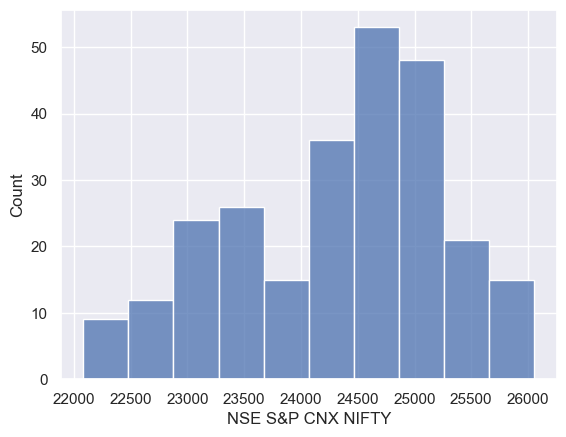

In [30]:
sns.histplot(data_cleaned['NSE S&P CNX NIFTY'],palette="green")
plt.savefig(r"C:\Users\abdur\Desktop\NiftyHistPlot.png")

The NIFTY index values are primarily concentrated between 24,000 and 25,200, indicating relatively stable market levels with moderate fluctuations during the study period

In [ ]:
sns.histplot(data_cleaned["RBI'S REFERENCE RATE: INR PER USD"])
plt.savefig(r"C:\Users\abdur\Desktop\Rbi_rate_histplot.png")

The RBI reference exchange rate is concentrated around 85–87 INR/USD, indicating relatively stable currency movements during the study period

In [ ]:
sns.histplot(data_cleaned['SP500'])
plt.savefig(r"C:\Users\abdur\Desktop\sp500histplot.png")

The S&P 500 index values are mostly concentrated around 5,900–6,200, indicating moderate fluctuations with a central tendency near 6,000 during the study period

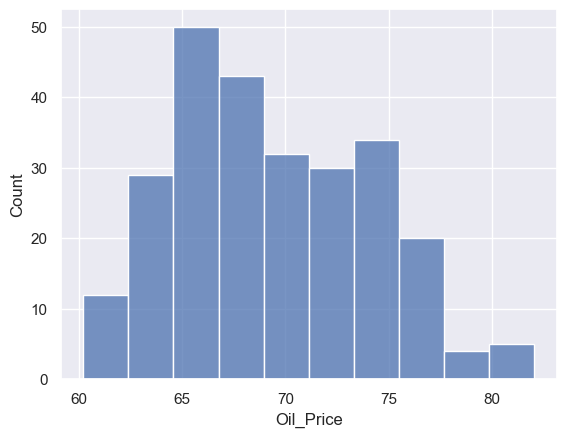

In [32]:
sns.histplot(data_cleaned['Oil_Price'])
plt.savefig(r"C:\Users\abdur\Desktop\oil_plot.png")

Brent crude oil prices are primarily concentrated between 65 and 75 USD per barrel, indicating moderate fluctuations with occasional higher price movements during the study period

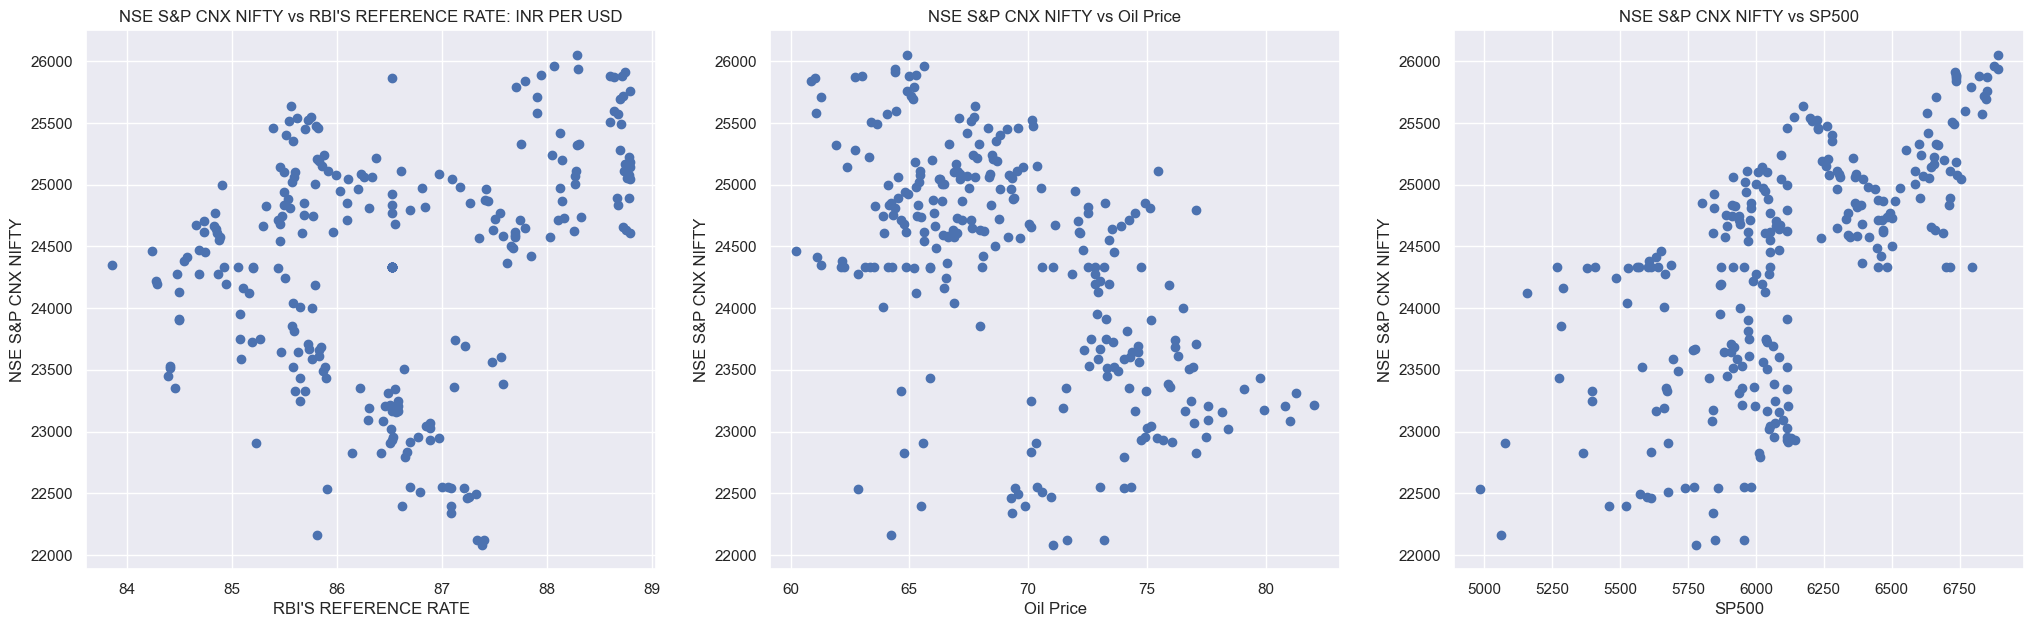

In [35]:
f,(ax1,ax2,ax3)=plt.subplots(1,3,figsize=(25,7))
ax1.scatter(data_cleaned["RBI'S REFERENCE RATE: INR PER USD"],data_cleaned['NSE S&P CNX NIFTY'])
ax1.set_title("NSE S&P CNX NIFTY vs RBI'S REFERENCE RATE: INR PER USD")
ax1.set_xlabel("RBI'S REFERENCE RATE")
ax1.set_ylabel("NSE S&P CNX NIFTY")
ax2.scatter(data_cleaned['Oil_Price'],data_cleaned['NSE S&P CNX NIFTY'])
ax2.set_title("NSE S&P CNX NIFTY vs Oil Price")
ax2.set_xlabel("Oil Price")
ax2.set_ylabel("NSE S&P CNX NIFTY")
ax3.scatter(data_cleaned['SP500'],data_cleaned['NSE S&P CNX NIFTY'])
ax3.set_title("NSE S&P CNX NIFTY vs SP500")
ax3.set_xlabel("SP500")
ax3.set_ylabel("NSE S&P CNX NIFTY")
plt.savefig(r"C:\Users\abdur\Desktop\NiftyVSMacroeconomicsScatter.png")
plt.show()


NIFTY vs Exchange Rate (USD/INR):The points are widely scattered without a clear upward or downward pattern
                                Changes in the USD/INR exchange rate do not strongly explain movements in the NIFTY index during this period. The stock                                  market may be influenced more by other macroeconomic or global factors
NIFTY vs Oil Price:The scatter plot shows a slight downward pattern as oil prices increase When oil prices increase, the NIFTY index tends to decrease.
                   This makes economic sense because India is a major importer of crude oil, and higher oil prices increase costs for businesses and the                    economy
NIFTY vs S&P 500:The points show a clear upward trend.
                 When the U.S. stock market rises, the Indian stock market often rises as well.
                 This reflects the global integration of financial markets and investor sentiment

Checking Multicollinearity

In [32]:
vif=pd.DataFrame()
variable=data_cleaned[['Oil_Price','SP500']]
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [33]:
vif['VIF']=[variance_inflation_factor(variable.values,i)
for i in range(variable.shape[1])]
vif['feautures']=variable.columns

In [34]:
vif

,VIF,feautures
0,91.050346,Oil_Price
1,91.050346,SP500


independent variable crude oil price and sp500 index are highly correlated therfore doing linear regression on both the variables simultaneously is not possible 